# Supervised Learning with Python

In this notebook, we'll put into practice: loading data, training a model, evaluating it, and comparing different models on a real dataset.

## 1. Setup

We'll use a handful of libraries: `pandas` (data), `numpy` (math), `matplotlib` (plots), `scikit-learn` (modeling), and `xgboost` (one of our models). All of these are pre-installed in Google Colab — nothing to install.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier

## 2. Data

We'll use the **Cleveland heart disease dataset** from the UCI Machine Learning Repository — the canonical dataset for this problem. It contains 13 clinical measurements for ~300 patients, plus a label indicating whether the patient has heart disease.

Each row is a patient. Each column is either a **feature** (e.g., age, cholesterol) or the **label** we're trying to predict (`target`: 1 = has heart disease, 0 = does not).

The UCI version comes raw — no header row, missing values written as `?`, and the original target column has severity levels 0–4. In reality data cleaning is a huge portion of the data science lifecycle, but for the purpose of this notebook we'll skip through this part so the rest of the notebook can focus on modeling:
- give the columns proper names,
- drop the handful of rows with missing values (~6 patients),
- binarize the target (0 = no disease, anything else = has disease).

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

df = pd.read_csv(DATA_URL, names=columns, na_values='?')

# Drop rows with missing values (~6 patients)
df = df.dropna().reset_index(drop=True)

# Binarize the target: 0 = no disease, 1+ = has disease
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


In [4]:
df['target'].value_counts()

,count
target,
0,160
1,137


The classes are reasonably balanced — about half the patients have heart disease.

> If this were highly imbalanced (e.g., 95% no disease, 5% disease), the **"accuracy lies"** problem from the slides would be more dramatic. We'll see why precision and recall are essential in that case.

## 3. Exploratory Data Analysis

Before modeling, it helps to get a visual sense of the data.

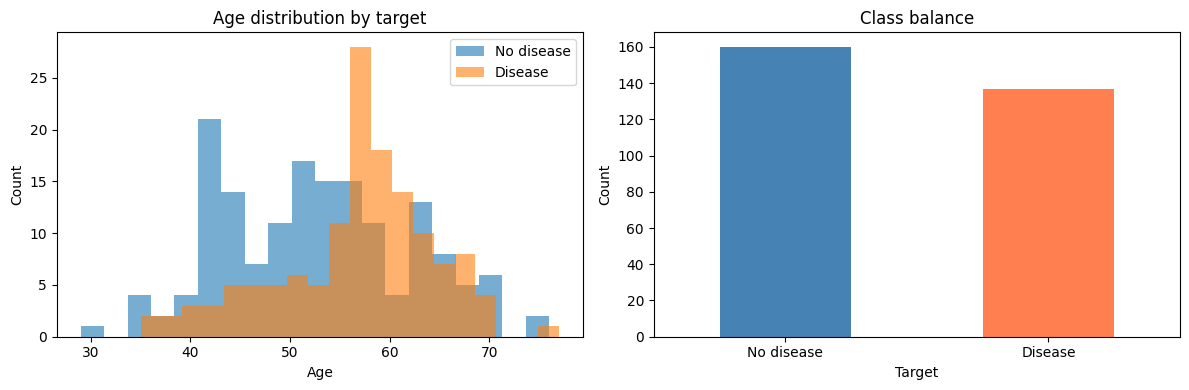

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution by target
axes[0].hist(df[df['target'] == 0]['age'], bins=20, alpha=0.6, label='No disease')
axes[0].hist(df[df['target'] == 1]['age'], bins=20, alpha=0.6, label='Disease')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age distribution by target')
axes[0].legend()

# Class balance
df['target'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Count')
axes[1].set_title('Class balance')
axes[1].set_xticklabels(['No disease', 'Disease'], rotation=0)

plt.tight_layout()
plt.show()

## 4. Features vs. label, train/test split

The **label** (`y`) is the column we want to predict — `target`.
All other columns are **features** (`X`) — measurements the model uses to make its prediction.

We split the data into:
- a **training set** the model learns from
- a **test set** we use to evaluate the model on data it has never seen

This is the only honest way to estimate how the model will perform on new patients in the real world.

In [6]:
X = df.drop(columns=['target'])   # features
y = df['target']                  # label

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of the data held out for testing
    random_state=42,    # for reproducibility
    stratify=y,         # keep the same class balance in both sets
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 237 rows
Test set:     60 rows


## 5. Model 1 — Logistic Regression

Logistic regression is the simplest baseline for binary classification. Recall from the slides: it's a weighted sum of the features squashed through a sigmoid to produce a probability.

The scikit-learn workflow is the same for every model: **create → fit → predict**.

In [7]:
# Create the model
log_reg = LogisticRegression(max_iter=1000)

# Fit it to the training data
log_reg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = log_reg.predict(X_test)

# Quick check: training and test accuracy
train_acc = log_reg.score(X_train, y_train)
test_acc  = log_reg.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.852
Test accuracy:  0.833


Let's peek at the **coefficients** — these tell us which features push predictions toward "has heart disease" (positive) and which push the other way (negative).

In [8]:
coef_df = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': log_reg.coef_[0],
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
11,ca,1.005223
1,sex,0.826717
8,exang,0.677524
2,cp,0.530884
10,slope,0.479581
9,oldpeak,0.411424
12,thal,0.407569
6,restecg,0.325145
3,trestbps,0.022842
4,chol,0.003759


## 6. Evaluation

Accuracy alone can be misleading. The slides showed why: on an imbalanced dataset, a model that always predicts the majority class can get high accuracy and still be useless.

Three essentials:
- **Confusion matrix** — counts of true positives, true negatives, false positives, false negatives.
- **Precision** — of the patients we *predicted* to have heart disease, how many actually did?
- **Recall** — of the patients who *actually had* heart disease, how many did we catch?

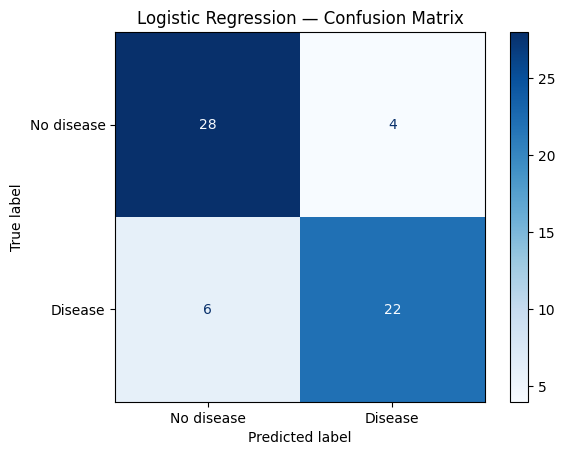

In [9]:
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No disease', 'Disease']).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [10]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.3f}")

Accuracy:  0.833
Precision: 0.846
Recall:    0.786


## 7. Model 2 — Decision Tree, and overfitting

A decision tree predicts by asking a sequence of yes/no questions about the features. The **`max_depth`** hyperparameter controls how many questions the tree can ask in a row — and therefore how complex the tree is.

Let's see what happens as we increase `max_depth`. We'll train a tree at each depth and plot train vs. test accuracy.

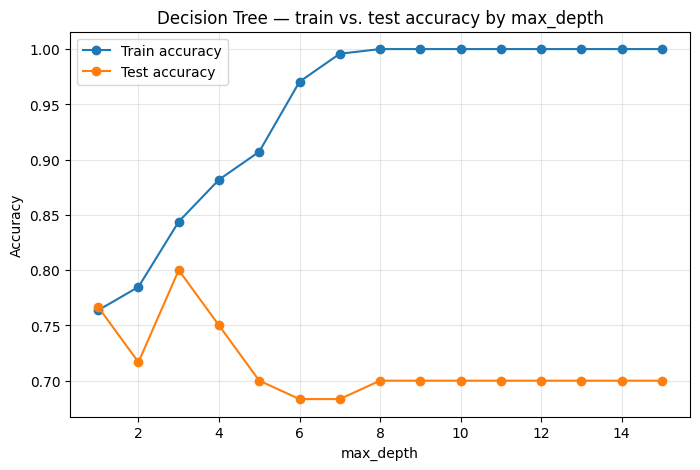

In [11]:
depths = range(1, 16)
train_scores = []
test_scores  = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker='o', label='Train accuracy')
plt.plot(depths, test_scores,  marker='o', label='Test accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — train vs. test accuracy by max_depth')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What's happening:**

- As `max_depth` grows, **training accuracy keeps climbing** — the tree is memorizing the training data.
- **Test accuracy plateaus or drops** — the tree is overfitting.

This is the overfitting curve from the slides, drawn from your own data. The "best" `max_depth` is wherever test accuracy peaks — not the deepest tree.

## 8. Hyperparameter tuning with `GridSearchCV`

The loop above tuned a single hyperparameter (`max_depth`). In practice, models have many hyperparameters, and you want to search over combinations.

**`GridSearchCV`** automates this. You give it:
- the model,
- a dictionary of hyperparameter values to try,
- a number of cross-validation folds (it splits the training data internally to evaluate each combination).

It tries every combination, runs cross-validation on each, and tells you which is best.

In [12]:
param_grid = {
    'max_depth':         [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy',
)
grid.fit(X_train, y_train)

print(f"Best parameters:  {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.3f}")
print(f"Test accuracy:    {grid.score(X_test, y_test):.3f}")

best_tree = grid.best_estimator_
y_pred_tree = best_tree.predict(X_test)

Best parameters:  {'max_depth': 3, 'min_samples_split': 2}
Best CV accuracy: 0.801
Test accuracy:    0.800


## 9. Model 3 — Random Forest

A **random forest** is an ensemble of many decision trees, each trained on a random subset of the data. The forest's prediction is the majority vote of all the trees. This usually generalizes better than any single tree.

Same fit / predict pattern — only the model class changes.

In [13]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, None],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
)
grid.fit(X_train, y_train)

print(f"Best parameters:  {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.3f}")
print(f"Test accuracy:    {grid.score(X_test, y_test):.3f}")

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

Best parameters:  {'max_depth': 5, 'n_estimators': 50}
Best CV accuracy: 0.831
Test accuracy:    0.817


## 10. Model 4 — XGBoost

**XGBoost** ("Extreme Gradient Boosting") is another tree-based ensemble — but instead of voting in parallel like random forests, it builds trees sequentially, each one correcting the previous one's mistakes. It's one of the most widely-used models in real-world tabular data competitions.

Same workflow yet again.

In [14]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 7],
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy',
)
grid.fit(X_train, y_train)

print(f"Best parameters:  {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.3f}")
print(f"Test accuracy:    {grid.score(X_test, y_test):.3f}")

best_xgb = grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

Best parameters:  {'max_depth': 7, 'n_estimators': 100}
Best CV accuracy: 0.801
Test accuracy:    0.867


## 11. Compare all four models

Now let's put them side by side on the test set — accuracy, precision, and recall for each.

In [15]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_tree),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_tree),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_tree),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_xgb)],
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.833333,0.846154,0.785714
1,Decision Tree,0.800000,0.785714,0.785714
2,Random Forest,0.816667,0.840000,0.750000
3,XGBoost,0.866667,0.884615,0.821429


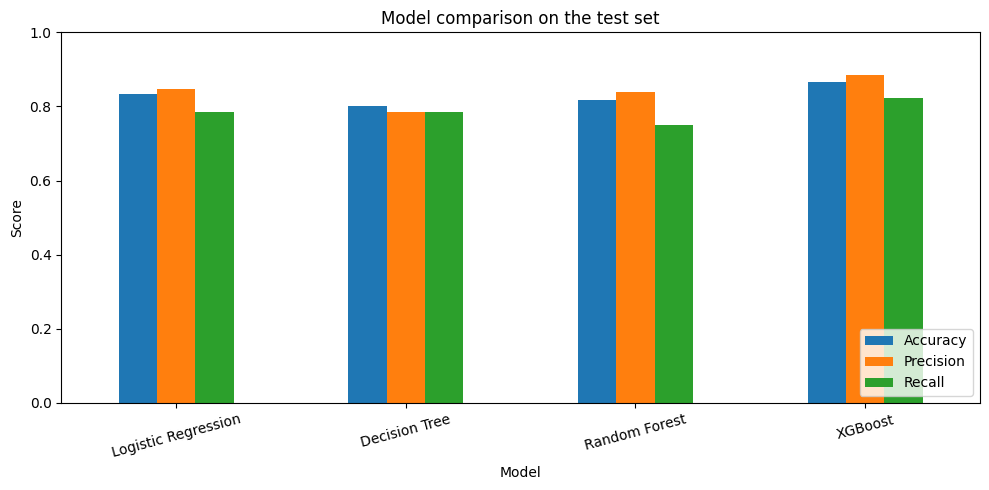

In [16]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(10, 5)
)
plt.ylabel('Score')
plt.title('Model comparison on the test set')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 12. Reflection

A few questions to think about:

- **Which model performed best on the test set?** Was it the most complex one?
- **Is the difference between models actually meaningful?** On a small dataset, small accuracy differences may not be real — they could be noise from a single train/test split.
- **For a medical-diagnosis task, would you optimize for accuracy, precision, or recall?**
  - High **recall** → fewer missed diagnoses (good for screening).
  - High **precision** → fewer false alarms (good when follow-up testing is expensive).
- **For a medical-diagnosis task, how important is it to have an interpretable (explainable) model?** Would you rather have an extremely interpretable model that performs slightly worse, or the most accurate model that is less interpretable?
- **What was the same across all four models?** The workflow: **load → split → fit → predict → evaluate**. Once you've learned this pattern, swapping in a new model is just one line of code.